# Module 3: ROI (Region of Interest) Detection
## QVSC Thesis — Canny Edge-Based Adaptive Mask Generation

**Author:** Hasibul Hasan (Roll: 2003127, CSE, RUET)

---

### What does this module do?

In video steganography, we hide secret data inside video frames. But we can't just hide data *anywhere* in the frame — if we embed data in **flat, smooth regions** (like a clear sky, a white wall, or a solid-color background), the changes become **visible to the human eye** as ugly blocking artifacts.

**Solution:** We use **Canny edge detection** to find regions with lots of texture, edges, and detail (trees, buildings, hair, grass, etc.). These "busy" regions can tolerate small changes without anyone noticing.

### The Algorithm at a Glance

```
1. Read a video frame (RGB image)
2. Convert RGB → YCrCb color space
3. Extract the Y (brightness/luminance) channel
4. Apply Gaussian blur to reduce noise
5. Run Canny edge detection on the Y channel
6. Dilate the edges to create connected regions
7. Divide the frame into 8×8 blocks
8. For each block: count edge pixels
   - If edge_density > 30% → Mark as "EMBED HERE" (mask = 1)
   - If edge_density ≤ 30% → Mark as "SKIP" (mask = 0)
9. Output: Binary mask telling us where to hide data
```

### Why is this a Novel Contribution?

Most video steganography systems embed data in **all** blocks blindly. Our adaptive ROI masking only embeds in textured blocks, which:
- Improves visual quality (higher PSNR and SSIM)
- Makes the stego video harder to detect by steganalysis tools
- Is reproducible on the receiver side (same algorithm → same mask)


In [1]:
# ============================================================
# STEP 1: Import all required libraries
# ============================================================
# We only need 3 libraries for this entire module!

import cv2          # OpenCV — the main image/video processing library
                    # We use it for: reading images, color conversion,
                    # edge detection, blurring, and dilation

import numpy as np  # NumPy — for working with arrays (images are just arrays)
                    # Every image in OpenCV is a NumPy array of pixel values

import matplotlib.pyplot as plt  # Matplotlib — for displaying images nicely
                                  # inside the notebook with titles and labels

print("✅ All libraries imported successfully!")
print(f"   OpenCV version: {cv2.__version__}")
print(f"   NumPy version:  {np.__version__}")


✅ All libraries imported successfully!
   OpenCV version: 5.0.0
   NumPy version:  2.5.1


## Step 1: Get a Video Frame to Work With

Before we can detect ROI regions, we need an image to work on. In the full QVSC pipeline, this would be a frame extracted from the cover video. For this demo, we'll **create a realistic test image** that has both textured regions (where we SHOULD embed) and flat regions (where we should NOT embed).

> **In the full pipeline:** You'd use `cv2.VideoCapture('cover_video.mp4')` to read frames from your actual cover video.


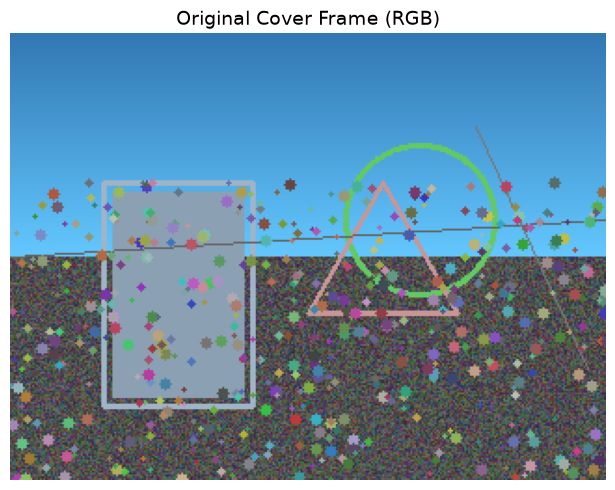

Frame shape: (240, 320, 3)
  → Height: 240 pixels
  → Width:  320 pixels
  → Channels: 3 (Blue, Green, Red)


In [2]:
# ============================================================
# STEP 2: Create a sample test frame (or load your own image)
# ============================================================

# --- OPTION A: Create a synthetic test image ---
# This image has both FLAT regions and TEXTURED regions,
# which is perfect for testing our ROI detection.

def create_test_frame(height=240, width=320):
    """
    Create a test image that has:
    - A flat gradient sky (top half) → should be SKIPPED (mask=0)
    - A textured ground with edges (bottom half) → should be EMBEDDED (mask=1)
    - Some geometric shapes with sharp edges → should be EMBEDDED (mask=1)
    
    This simulates a real video frame where some areas are smooth
    and some areas have lots of detail.
    """
    # Start with a blank canvas (all zeros = black)
    frame = np.zeros((height, width, 3), dtype=np.uint8)
    
    # --- TOP HALF: Smooth gradient sky (FLAT region) ---
    # A gradient has no edges, so our algorithm should SKIP this area.
    # We create a smooth blue-to-light-blue gradient.
    for y in range(height // 2):
        # As y increases (going down), the sky gets lighter
        blue_value = 180 + int(75 * y / (height // 2))   # 180 → 255
        green_value = 120 + int(80 * y / (height // 2))   # 120 → 200
        red_value = 50 + int(50 * y / (height // 2))      # 50 → 100
        frame[y, :] = [blue_value, green_value, red_value]  # BGR format in OpenCV
    
    # --- BOTTOM HALF: Textured ground (HIGH-DETAIL region) ---
    # Random noise + patterns simulate grass, gravel, buildings, etc.
    # These areas have lots of edges, so our algorithm should SELECT them.
    ground = np.random.randint(40, 120, (height // 2, width, 3), dtype=np.uint8)
    frame[height // 2:, :] = ground
    
    # --- Add geometric shapes (EDGES that should be detected) ---
    # Rectangle (like a building)
    cv2.rectangle(frame, (50, 80), (130, 200), (200, 180, 160), 2)
    cv2.rectangle(frame, (55, 85), (125, 195), (180, 160, 140), -1)  # filled
    
    # Circle (like a ball or sign)
    cv2.circle(frame, (220, 100), 40, (100, 200, 100), 2)
    
    # Triangle (like a roof)
    triangle = np.array([[160, 150], [200, 80], [240, 150]], np.int32)
    cv2.polylines(frame, [triangle], True, (150, 150, 200), 2)
    
    # Some lines (like power lines or branches)
    cv2.line(frame, (0, 120), (320, 100), (100, 100, 100), 1)
    cv2.line(frame, (250, 50), (310, 180), (120, 120, 120), 1)
    
    # Add some texture patches (like tree foliage)
    for _ in range(500):
        x = np.random.randint(0, width)
        y = np.random.randint(height // 3, height)
        color = tuple(np.random.randint(50, 200, 3).tolist())
        cv2.circle(frame, (x, y), np.random.randint(1, 4), color, -1)
    
    return frame


# --- OPTION B: Load your own image (uncomment the lines below) ---
# frame = cv2.imread('your_video_frame.png')  # reads in BGR format
# frame = cv2.resize(frame, (320, 240))       # resize if needed

# Create our test frame
frame_bgr = create_test_frame(height=240, width=320)

# Display the frame
# Note: OpenCV uses BGR, but matplotlib uses RGB, so we convert for display
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 5))
plt.imshow(frame_rgb)
plt.title("Original Cover Frame (RGB)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Frame shape: {frame_bgr.shape}")
print(f"  → Height: {frame_bgr.shape[0]} pixels")
print(f"  → Width:  {frame_bgr.shape[1]} pixels")
print(f"  → Channels: {frame_bgr.shape[2]} (Blue, Green, Red)")


## Step 2: Convert RGB → YCrCb and Extract the Y Channel

### Why convert to YCrCb?

Our eyes are much more sensitive to **brightness changes** than **color changes**. The YCrCb color space separates these:

| Channel | Name | What it represents | Human sensitivity |
|---------|------|--------------------|-------------------|
| **Y** | Luminance | Brightness (light/dark) | **Very high** — we notice changes here |
| **Cr** | Red Chrominance | How "red" vs "cyan" a pixel is | Low — we barely notice changes |
| **Cb** | Blue Chrominance | How "blue" vs "yellow" a pixel is | Low — we barely notice changes |

### Why do we use Y for edge detection?

We detect edges on the **Y channel** because:
1. Edges in brightness (Y) correspond to object boundaries — exactly what we want
2. The Y channel captures the most structural information about the scene
3. Color edges (in Cr/Cb) might not correspond to actual texture

### Where do we embed the data?

We **detect** ROI on the **Y channel** (edges show up best there) and we also
**embed** in the **Y channel** (Module 4). Earlier designs used Cr, but H.264's
4:2:0 chroma subsampling halves the chroma resolution and destroys Cr-embedded
data (~50% bit errors). Y is kept at full resolution, so the payload survives
compression. Visibility is kept low by embedding only in textured ROI blocks
and by informed embedding in Module 4 (PSNR ~48 dB).


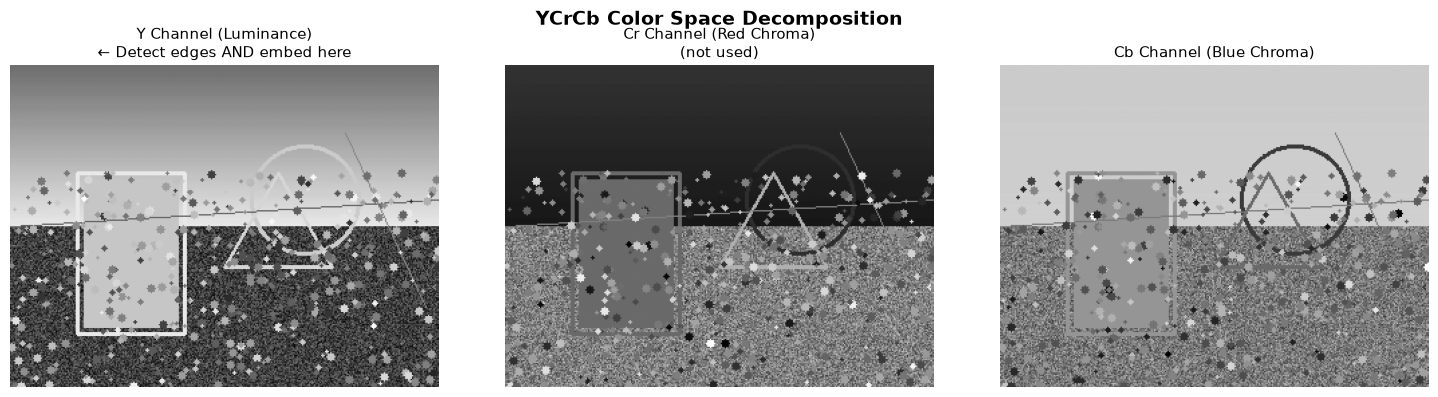

Y channel shape:  (240, 320)  (2D grayscale image)
Y channel dtype:  uint8
Y value range:    [42, 189]


In [3]:
# ============================================================
# STEP 3: Convert BGR → YCrCb and extract the Y channel
# ============================================================

# Convert from BGR (OpenCV's default) to YCrCb color space
# OpenCV does this using a standard formula:
#   Y  = 0.299 × R + 0.587 × G + 0.114 × B
#   Cr = (R - Y) × 0.713 + 128
#   Cb = (B - Y) × 0.564 + 128
frame_ycrcb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)

# Extract the three channels
# channel 0 = Y (luminance/brightness)
# channel 1 = Cr (red chrominance) — NOT used for embedding
# channel 2 = Cb (blue chrominance)
y_channel  = frame_ycrcb[:, :, 0]   # shape: (240, 320) — just a 2D grayscale image
cr_channel = frame_ycrcb[:, :, 1]
cb_channel = frame_ycrcb[:, :, 2]

# Display all three channels side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(y_channel, cmap='gray')
axes[0].set_title("Y Channel (Luminance)\n← Detect edges AND embed here", fontsize=11)
axes[0].axis('off')

axes[1].imshow(cr_channel, cmap='gray')
axes[1].set_title("Cr Channel (Red Chroma)\n(not used)", fontsize=11)
axes[1].axis('off')

axes[2].imshow(cb_channel, cmap='gray')
axes[2].set_title("Cb Channel (Blue Chroma)", fontsize=11)
axes[2].axis('off')

plt.suptitle("YCrCb Color Space Decomposition", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Y channel shape:  {y_channel.shape}  (2D grayscale image)")
print(f"Y channel dtype:  {y_channel.dtype}")
print(f"Y value range:    [{y_channel.min()}, {y_channel.max()}]")


## Step 3: Apply Gaussian Blur to Reduce Noise

Before running edge detection, we **smooth the image slightly** using a Gaussian blur. This is important because:

1. **Real images have noise** — random pixel variations from the camera sensor
2. **Noise creates fake edges** — Canny would detect noise as edges, which we don't want
3. **Gaussian blur removes high-frequency noise** while keeping real edges mostly intact

The blur uses a **5×5 kernel** with **σ = 1.0**. Think of it as replacing each pixel with the weighted average of its neighbors, where closer neighbors have more weight (following a bell curve / Gaussian distribution).


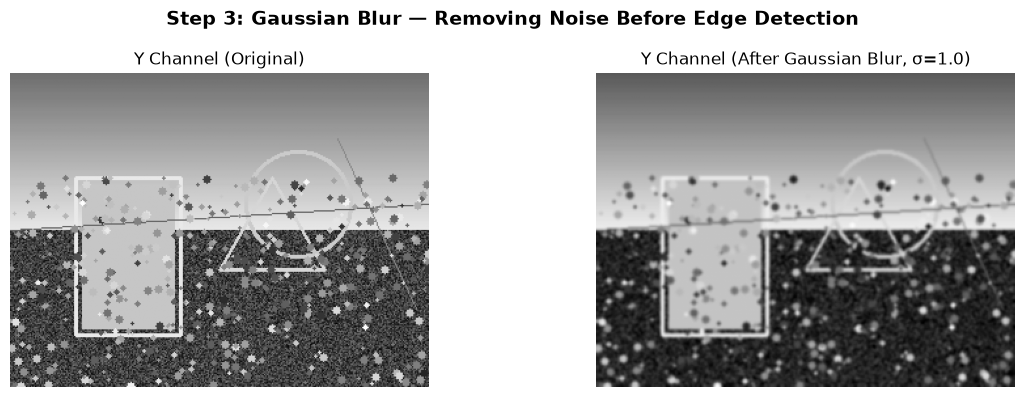

The blur is subtle — that's intentional!
We want to remove noise, not destroy the actual edges.


In [4]:
# ============================================================
# STEP 4: Apply Gaussian blur to the Y channel
# ============================================================

# Parameters:
# - (5, 5) = kernel size (5×5 pixel neighborhood)
# - 1.0 = sigma (σ) — controls how much blurring
#   Small σ → light blur (keeps more detail)
#   Large σ → heavy blur (removes more detail)
#   σ = 1.0 is a good balance for edge detection

y_blurred = cv2.GaussianBlur(
    y_channel,     # input: the Y (brightness) channel
    (5, 5),        # kernel size: 5×5 pixels
    1.0            # sigma: standard deviation of the Gaussian
)

# Show the difference between original and blurred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(y_channel, cmap='gray')
axes[0].set_title("Y Channel (Original)", fontsize=12)
axes[0].axis('off')

axes[1].imshow(y_blurred, cmap='gray')
axes[1].set_title("Y Channel (After Gaussian Blur, σ=1.0)", fontsize=12)
axes[1].axis('off')

plt.suptitle("Step 3: Gaussian Blur — Removing Noise Before Edge Detection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("The blur is subtle — that's intentional!")
print("We want to remove noise, not destroy the actual edges.")


## Step 4: Canny Edge Detection — The Core of ROI Detection

Canny edge detection is a multi-step algorithm that finds edges in an image. Here's what it does internally (OpenCV handles all of this for us with one function call):

### Inside `cv2.Canny()` — What happens step by step:

**Step A — Compute Gradients:** Apply Sobel filters to find how quickly pixel intensity changes in the X and Y directions. The gradient magnitude tells us "how strong is the edge here?"

$$G = \sqrt{G_x^2 + G_y^2}$$

**Step B — Non-Maximum Suppression:** Thin the edges to 1-pixel width. For each pixel, check if it's the local maximum along the gradient direction. If not, suppress it (set to 0).

**Step C — Double Thresholding:** Apply two thresholds:
- **High threshold (150):** Pixels with gradient > 150 are **definitely edges** (strong edges)
- **Low threshold (50):** Pixels with gradient between 50-150 are **maybe edges** (weak edges)
- Pixels with gradient < 50 are **definitely NOT edges**

**Step D — Edge Tracking by Hysteresis:** Weak edges are only kept if they're **connected to a strong edge**. This removes isolated noise while keeping real edge lines complete.

### Our threshold choices: `low=50, high=150`
- **Too low** → too many edges (noise gets detected as edges)
- **Too high** → too few edges (we miss real texture)
- **50 and 150** → good balance for video frames (validated by QSAC paper)


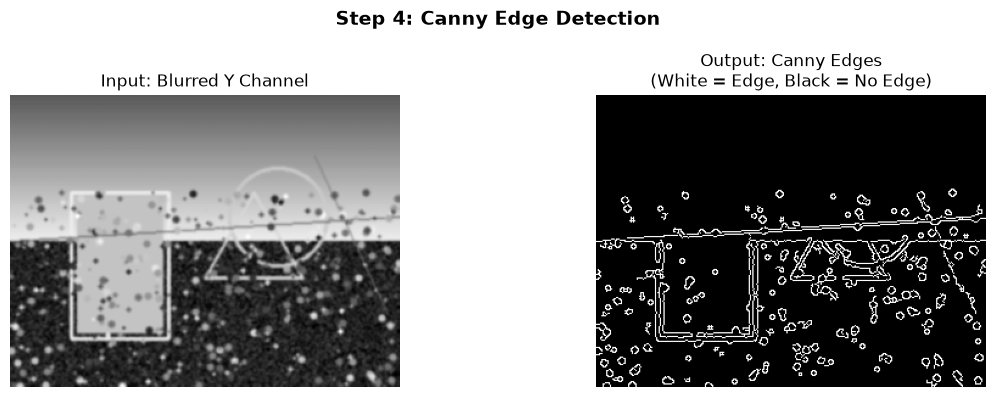

Total pixels:     76,800
Edge pixels:      5,309
Edge percentage:  6.9%


In [5]:
# ============================================================
# STEP 5: Run Canny edge detection
# ============================================================

# Canny edge detection parameters
CANNY_LOW = 50     # low threshold — weak edges below this are discarded
CANNY_HIGH = 150   # high threshold — strong edges above this are kept
                   # Weak edges (between 50-150) are kept only if
                   # they're connected to a strong edge

# Run Canny on the blurred Y channel
# Output: a binary image where white (255) = edge, black (0) = no edge
edges = cv2.Canny(
    y_blurred,     # input: the blurred Y channel
    CANNY_LOW,     # low threshold
    CANNY_HIGH     # high threshold
)

# Display the edge map
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(y_blurred, cmap='gray')
axes[0].set_title("Input: Blurred Y Channel", fontsize=12)
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title("Output: Canny Edges\n(White = Edge, Black = No Edge)", fontsize=12)
axes[1].axis('off')

plt.suptitle("Step 4: Canny Edge Detection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Count how many edge pixels were found
total_pixels = edges.shape[0] * edges.shape[1]
edge_pixels = np.count_nonzero(edges)
print(f"Total pixels:     {total_pixels:,}")
print(f"Edge pixels:      {edge_pixels:,}")
print(f"Edge percentage:  {100 * edge_pixels / total_pixels:.1f}%")


## Step 5: Dilate the Edges to Create Connected Regions

After Canny, the edges are thin 1-pixel lines. But we want to identify **regions** (areas), not just lines. Dilation **expands** each edge pixel outward, making the edges thicker and connecting nearby edges into continuous regions.

Think of it like using a **thick marker instead of a thin pen** — the lines get fatter and nearby lines merge together.

### How dilation works:
- We slide a small square kernel (3×3) over every pixel
- If **any** neighbor within the kernel is an edge pixel (255), the center pixel becomes an edge too
- We repeat this 2 times (`iterations=2`) for more expansion


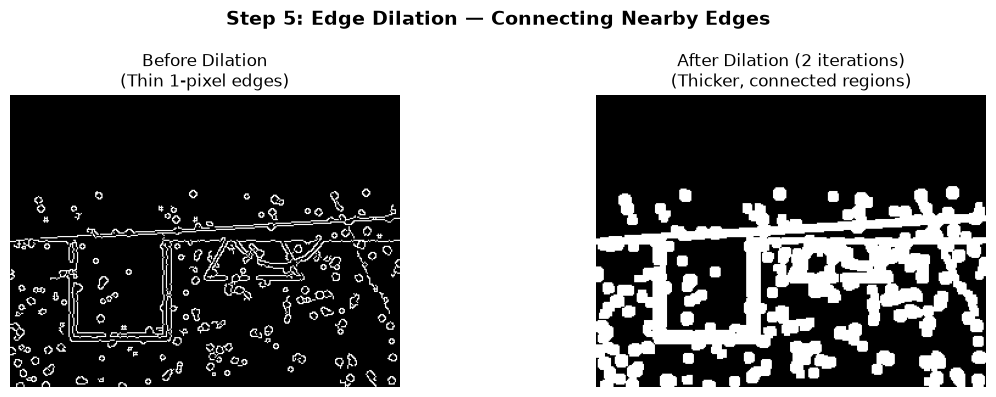

Edge pixels before dilation: 5,309
Edge pixels after dilation:  22,489
Expansion ratio: 4.2x


In [6]:
# ============================================================
# STEP 6: Dilate the edges to create connected regions
# ============================================================

# Create a 3×3 square structuring element (kernel)
# This is the "brush" that expands the edges
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,  # shape: rectangle (square in this case)
    (3, 3)           # size: 3×3 pixels
)

# Dilate the edge map
# iterations=2 means we apply dilation twice
# Each iteration expands edges by ~1 pixel in each direction
# So 2 iterations → edges expand by ~2 pixels total
edges_dilated = cv2.dilate(
    edges,         # input: the thin Canny edges
    kernel,        # the structuring element
    iterations=2   # how many times to apply dilation
)

# Show the difference
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(edges, cmap='gray')
axes[0].set_title("Before Dilation\n(Thin 1-pixel edges)", fontsize=12)
axes[0].axis('off')

axes[1].imshow(edges_dilated, cmap='gray')
axes[1].set_title("After Dilation (2 iterations)\n(Thicker, connected regions)", fontsize=12)
axes[1].axis('off')

plt.suptitle("Step 5: Edge Dilation — Connecting Nearby Edges", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

edge_pixels_before = np.count_nonzero(edges)
edge_pixels_after = np.count_nonzero(edges_dilated)
print(f"Edge pixels before dilation: {edge_pixels_before:,}")
print(f"Edge pixels after dilation:  {edge_pixels_after:,}")
print(f"Expansion ratio: {edge_pixels_after / max(edge_pixels_before, 1):.1f}x")


## Step 6: Generate the Block-Level Binary Mask

This is the final and most important step! We divide the entire frame into **8×8 pixel blocks** and decide for each block: **"Should we embed data here or not?"**

### Why 8×8 blocks?
- The DCT transform in Module 4 operates on 8×8 blocks
- H.264 video compression also uses 8×8 (and 4×4) blocks internally
- So our mask needs to align with the same block grid

### The Decision Rule
For each 8×8 block, we count how many pixels are edge pixels (white in the dilated edge map). If the **edge density** (percentage of edge pixels) exceeds a threshold (30%), we mark the block as "suitable for embedding."

```
edge_density = (number of edge pixels in this block) / 64

If edge_density > 0.30 → mask[block] = 1  (EMBED HERE — lots of texture)
If edge_density ≤ 0.30 → mask[block] = 0  (SKIP — too smooth/flat)
```

The **30% threshold** means at least 20 out of 64 pixels must be edge pixels. This ensures we only embed in genuinely textured areas.


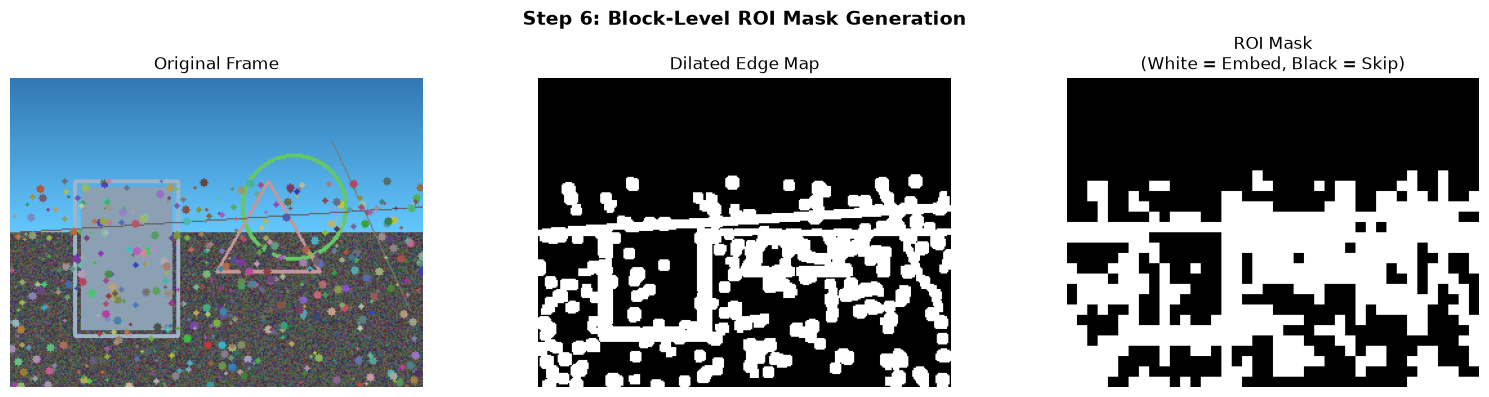

Block size:       8×8 pixels
Total blocks:     1200
ROI blocks:       458 (embed here)
Skipped blocks:   742 (too flat)
ROI percentage:   38.2%

Embedding capacity: 458 bits = 57 bytes
  (1 bit per block, using DCT coefficient at position (4,5))


In [7]:
# ============================================================
# STEP 7: Generate the block-level binary mask
# ============================================================

# Parameters
BLOCK_SIZE = 8              # 8×8 pixel blocks (matches DCT block size)
EDGE_DENSITY_THRESHOLD = 0.30  # 30% — at least 20/64 pixels must be edges

def generate_roi_mask(edges_dilated, block_size=8, threshold=0.30):
    """
    Generate a binary mask that tells us WHERE to embed data.
    
    Parameters:
    -----------
    edges_dilated : numpy array (H × W), uint8
        The dilated edge map (255 = edge, 0 = no edge)
    block_size : int
        Size of each block (8 for DCT compatibility)
    threshold : float
        Minimum edge density (0.30 = 30%) to mark a block as ROI
    
    Returns:
    --------
    mask : numpy array (H × W), uint8
        Binary mask: 1 = embed here, 0 = skip this block
    num_roi_blocks : int
        How many blocks are marked for embedding
    total_blocks : int
        Total number of complete blocks in the frame
    """
    height, width = edges_dilated.shape
    
    # Create an empty mask (all zeros = "skip everything" initially)
    mask = np.zeros((height, width), dtype=np.uint8)
    
    # Count blocks
    num_roi_blocks = 0
    total_blocks = 0
    
    # Total pixels in one block
    pixels_per_block = block_size * block_size  # 8 × 8 = 64
    
    # Loop through the frame, block by block
    # We step by 'block_size' in both directions
    for row in range(0, height - block_size + 1, block_size):
        for col in range(0, width - block_size + 1, block_size):
            total_blocks += 1
            
            # Extract the 8×8 region from the dilated edge map
            block = edges_dilated[row : row + block_size,
                                  col : col + block_size]
            
            # Count how many pixels in this block are edges (value = 255)
            edge_count = np.count_nonzero(block)
            
            # Calculate edge density (what fraction of pixels are edges)
            edge_density = edge_count / pixels_per_block
            
            # Decision: is this block textured enough?
            if edge_density > threshold:
                # YES — mark this entire 8×8 region as "embed here"
                mask[row : row + block_size,
                     col : col + block_size] = 1
                num_roi_blocks += 1
    
    return mask, num_roi_blocks, total_blocks


# Generate the mask
mask, num_roi_blocks, total_blocks = generate_roi_mask(
    edges_dilated,
    block_size=BLOCK_SIZE,
    threshold=EDGE_DENSITY_THRESHOLD
)

# Display the mask
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].imshow(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Frame", fontsize=12)
axes[0].axis('off')

axes[1].imshow(edges_dilated, cmap='gray')
axes[1].set_title("Dilated Edge Map", fontsize=12)
axes[1].axis('off')

axes[2].imshow(mask, cmap='gray')
axes[2].set_title("ROI Mask\n(White = Embed, Black = Skip)", fontsize=12)
axes[2].axis('off')

plt.suptitle("Step 6: Block-Level ROI Mask Generation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print statistics
print(f"Block size:       {BLOCK_SIZE}×{BLOCK_SIZE} pixels")
print(f"Total blocks:     {total_blocks}")
print(f"ROI blocks:       {num_roi_blocks} (embed here)")
print(f"Skipped blocks:   {total_blocks - num_roi_blocks} (too flat)")
print(f"ROI percentage:   {100 * num_roi_blocks / total_blocks:.1f}%")
print(f"\nEmbedding capacity: {num_roi_blocks} bits = {num_roi_blocks // 8} bytes")
print(f"  (1 bit per block, using DCT coefficient at position (4,5))")


## Step 7: Visualize — Overlay the Mask on the Original Frame

Let's see exactly which parts of the frame are selected for embedding. Green regions = embed here. This visualization helps us verify that:
- Flat areas (sky, smooth gradients) are correctly **skipped**
- Textured areas (objects, edges, noise) are correctly **selected**


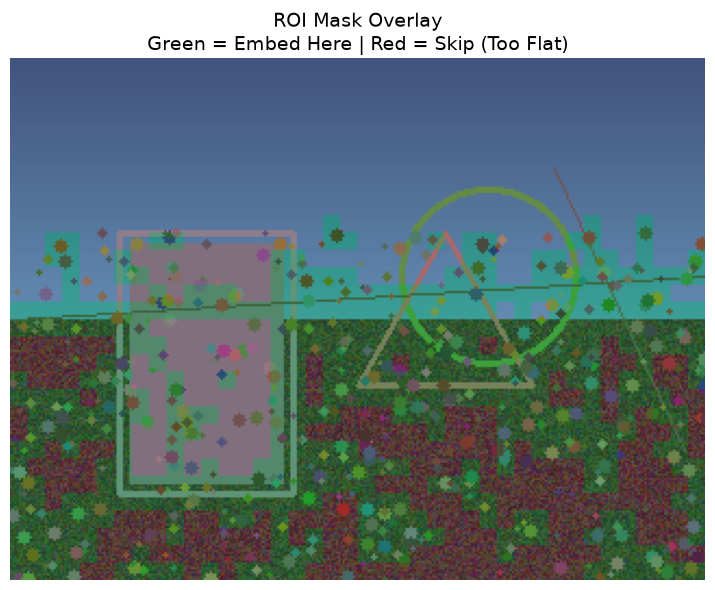

✅ Green areas: High texture — data will be hidden here (imperceptible)
❌ Red areas:   Flat/smooth — skipped to avoid visible artifacts


In [8]:
# ============================================================
# STEP 8: Overlay the mask on the original frame for visualization
# ============================================================

def visualize_mask_overlay(frame_bgr, mask):
    """
    Create a visualization showing:
    - Green tint on blocks marked for embedding (mask=1)
    - Red tint on blocks that are skipped (mask=0)
    """
    # Convert frame to RGB for display
    overlay = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB).copy().astype(np.float32)
    
    # Where mask = 1 (embed), add a green tint
    green_tint = np.zeros_like(overlay)
    green_tint[:, :, 1] = 100  # green channel boost
    overlay[mask == 1] = overlay[mask == 1] * 0.6 + green_tint[mask == 1] * 0.4
    
    # Where mask = 0 (skip), add a slight red tint
    red_tint = np.zeros_like(overlay)
    red_tint[:, :, 0] = 100  # red channel boost
    overlay[mask == 0] = overlay[mask == 0] * 0.7 + red_tint[mask == 0] * 0.3
    
    # Clip values to valid range [0, 255]
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    
    return overlay


overlay = visualize_mask_overlay(frame_bgr, mask)

plt.figure(figsize=(10, 6))
plt.imshow(overlay)
plt.title("ROI Mask Overlay\nGreen = Embed Here | Red = Skip (Too Flat)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

print("✅ Green areas: High texture — data will be hidden here (imperceptible)")
print("❌ Red areas:   Flat/smooth — skipped to avoid visible artifacts")


## Complete Module 3 Function — Ready for the Pipeline

Below is the **complete, self-contained function** that you'll call from the main QVSC pipeline. It takes a frame and returns a binary mask. Both the sender (for embedding) and receiver (for extraction) run this **exact same function** to get the same mask.

### Critical for the receiver:
The receiver MUST use the **same parameters** (thresholds, kernel size, block size) to regenerate the same mask. Otherwise, they'll look at the wrong blocks and extract garbage.


In [9]:
# ============================================================
# COMPLETE MODULE 3: ROI Detection Function
# ============================================================
# This is the function you'll import and use in the full pipeline.
# Both SENDER and RECEIVER call this with the SAME parameters.

def detect_roi(frame_bgr, 
               block_size=8, 
               canny_low=50, 
               canny_high=150, 
               blur_sigma=1.0,
               dilate_iterations=2,
               edge_threshold=0.30,
               verbose=False):
    """
    Detect Regions of Interest (ROI) for steganographic embedding.
    
    This function identifies textured blocks in a video frame where
    data can be hidden without visible artifacts. It uses Canny edge
    detection to find high-detail areas and creates a binary mask.
    
    Parameters:
    -----------
    frame_bgr : numpy array (H × W × 3), uint8
        Input frame in BGR color format (as read by OpenCV)
    block_size : int, default=8
        Size of blocks (must match DCT block size in Module 4)
    canny_low : int, default=50
        Canny edge detection lower threshold
    canny_high : int, default=150
        Canny edge detection upper threshold
    blur_sigma : float, default=1.0
        Gaussian blur sigma (standard deviation)
    dilate_iterations : int, default=2
        Number of dilation iterations
    edge_threshold : float, default=0.30
        Minimum edge density to mark block as ROI (0.30 = 30%)
    verbose : bool, default=False
        If True, print step-by-step information
    
    Returns:
    --------
    mask : numpy array (H × W), uint8
        Binary mask: 1 = embed here, 0 = skip
    roi_block_count : int
        Number of blocks marked for embedding
    total_block_count : int
        Total number of complete 8×8 blocks
    
    Usage:
    ------
    # Sender side:
    mask, n_roi, n_total = detect_roi(frame)
    
    # Receiver side (MUST produce identical mask):
    mask, n_roi, n_total = detect_roi(received_frame)
    """
    
    if verbose:
        print("=" * 50)
        print("MODULE 3: ROI Detection")
        print("=" * 50)
    
    # --- Step 1: Convert to YCrCb, extract Y channel ---
    frame_ycrcb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)
    y_channel = frame_ycrcb[:, :, 0]
    if verbose:
        print(f"[Step 1] Converted to YCrCb. Y channel shape: {y_channel.shape}")
    
    # --- Step 2: Gaussian blur ---
    y_blurred = cv2.GaussianBlur(y_channel, (5, 5), blur_sigma)
    if verbose:
        print(f"[Step 2] Applied Gaussian blur (σ={blur_sigma})")
    
    # --- Step 3: Canny edge detection ---
    edges = cv2.Canny(y_blurred, canny_low, canny_high)
    if verbose:
        edge_pct = 100 * np.count_nonzero(edges) / edges.size
        print(f"[Step 3] Canny edges detected ({edge_pct:.1f}% of pixels are edges)")
    
    # --- Step 4: Dilate edges ---
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edges_dilated = cv2.dilate(edges, kernel, iterations=dilate_iterations)
    if verbose:
        print(f"[Step 4] Dilated edges ({dilate_iterations} iterations)")
    
    # --- Step 5: Generate block-level mask ---
    height, width = edges_dilated.shape
    mask = np.zeros((height, width), dtype=np.uint8)
    pixels_per_block = block_size * block_size
    
    roi_block_count = 0
    total_block_count = 0
    
    for row in range(0, height - block_size + 1, block_size):
        for col in range(0, width - block_size + 1, block_size):
            total_block_count += 1
            
            block = edges_dilated[row : row + block_size,
                                  col : col + block_size]
            edge_density = np.count_nonzero(block) / pixels_per_block
            
            if edge_density > edge_threshold:
                mask[row : row + block_size, col : col + block_size] = 1
                roi_block_count += 1
    
    if verbose:
        print(f"[Step 5] Mask generated:")
        print(f"         Total blocks:  {total_block_count}")
        print(f"         ROI blocks:    {roi_block_count} ({100*roi_block_count/total_block_count:.1f}%)")
        print(f"         Capacity:      {roi_block_count} bits = {roi_block_count//8} bytes")
        print("=" * 50)
    
    return mask, roi_block_count, total_block_count


# --- TEST the complete function ---
print("Testing the complete detect_roi() function:\n")
mask, n_roi, n_total = detect_roi(frame_bgr, verbose=True)


Testing the complete detect_roi() function:

MODULE 3: ROI Detection
[Step 1] Converted to YCrCb. Y channel shape: (240, 320)
[Step 2] Applied Gaussian blur (σ=1.0)
[Step 3] Canny edges detected (6.9% of pixels are edges)
[Step 4] Dilated edges (2 iterations)
[Step 5] Mask generated:
         Total blocks:  1200
         ROI blocks:    458 (38.2%)
         Capacity:      458 bits = 57 bytes


## Bonus: How Does the Edge Threshold Affect the Mask?

Let's see what happens when we change the edge density threshold. This helps you understand why 30% is a good default and how to tune it for different video content.


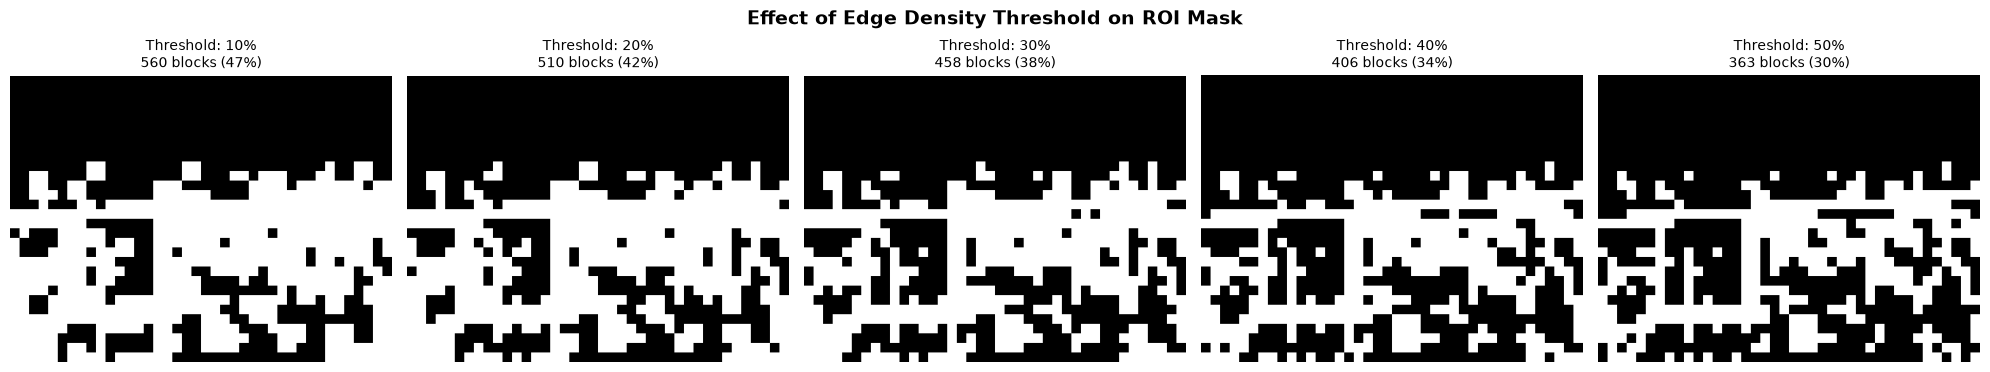

Lower threshold → more blocks selected → higher capacity but lower quality
Higher threshold → fewer blocks selected → lower capacity but higher quality

30% is the sweet spot for most video content in our QVSC system.


In [10]:
# ============================================================
# BONUS: Compare different edge density thresholds
# ============================================================

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50]

fig, axes = plt.subplots(1, len(thresholds), figsize=(20, 4))

for i, thresh in enumerate(thresholds):
    m, n_roi, n_total = detect_roi(frame_bgr, edge_threshold=thresh)
    axes[i].imshow(m, cmap='gray')
    pct = 100 * n_roi / n_total
    axes[i].set_title(f"Threshold: {thresh:.0%}\n{n_roi} blocks ({pct:.0f}%)", fontsize=10)
    axes[i].axis('off')

plt.suptitle("Effect of Edge Density Threshold on ROI Mask", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Lower threshold → more blocks selected → higher capacity but lower quality")
print("Higher threshold → fewer blocks selected → lower capacity but higher quality")
print("\n30% is the sweet spot for most video content in our QVSC system.")


## How the Receiver Uses This Module

The system is **non-blind**. The sender's ROI masks (`roi_masks.npy`) are
shared with the receiver as side-information, and Module 5 extracts using those
exact masks — it does NOT regenerate them. Regenerated masks agree only ~97%
with the sender's, and because bits are packed sequentially into ROI blocks,
even one mismatched block desynchronizes the whole bitstream (~50% BER).

```python
# === SENDER SIDE (Module 3 + Module 4) ===
mask, _, _ = detect_roi(cover_frame)        # find where to embed
stego_frame = dct_qim_embed(cover_frame, mask, secret_bits, delta=50)  # Y channel

# === RECEIVER SIDE (Module 5) ===
mask = sender_masks[frame_index]            # use the TRANSMITTED mask (non-blind)
extracted_bits = dct_qim_extract(stego_frame, mask, delta=50)
```

### The detection parameters must stay fixed (sender + diagnostic):
1. Canny thresholds (50, 150)
2. Gaussian blur (σ=1.0)
3. Dilation (3×3 kernel, 2 iterations)
4. Edge density threshold (30%)
5. Block size (8×8)

Determinism still matters as a **diagnostic** (it explains the ~97% agreement),
but extraction relies on the transmitted masks, not regeneration.

---

### Summary of Module 3 Parameters

| Parameter | Value | Why this value |
|-----------|-------|----------------|
| Color space | YCrCb | Separates brightness from color |
| Edge detection channel | Y (luminance) | Best for structural edges |
| Gaussian blur σ | 1.0 | Removes noise without destroying edges |
| Canny low threshold | 50 | Keeps weak edges connected to strong ones |
| Canny high threshold | 150 | Detects strong edges reliably |
| Dilation kernel | 3×3 rect | Standard morphological element |
| Dilation iterations | 2 | Creates connected regions |
| Block size | 8×8 | Matches DCT block size |
| Edge density threshold | 30% | Good balance: quality vs. capacity |


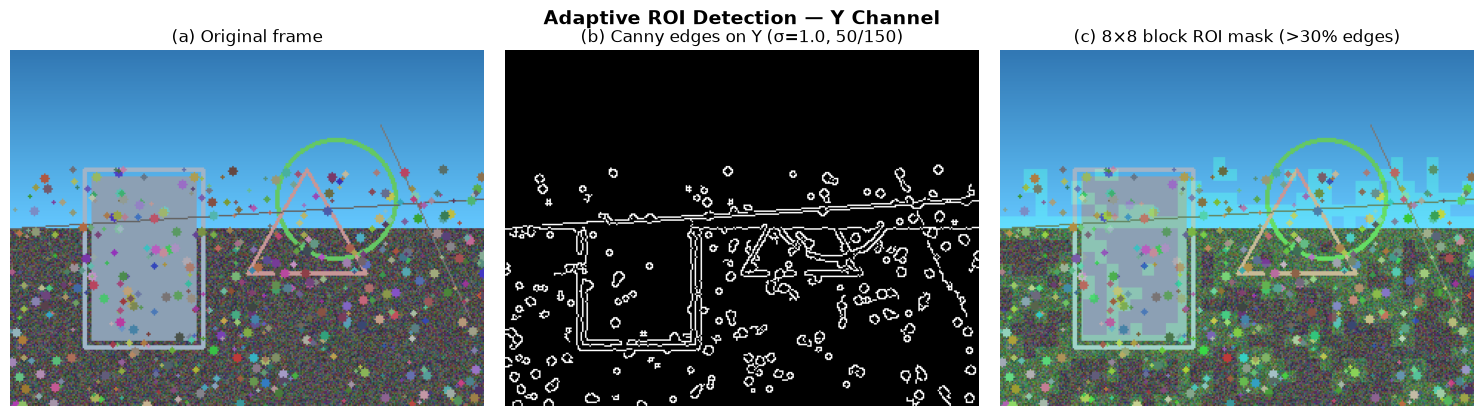

Saved roi_detection.png  |  ROI blocks: 458 / 1200


In [11]:
# ============================================================
# PRESENTATION FIGURE — 3-panel ROI image for the seminar slide
# Saves: roi_detection.png  (move it into your deck's figs/ folder)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np, cv2

# Recompute the ROI pipeline on the loaded frame (self-contained)
_ycc   = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)
_y     = _ycc[:, :, 0]
_blur  = cv2.GaussianBlur(_y, (5, 5), 1.0)
_edges = cv2.Canny(_blur, 50, 150)
_dil   = cv2.dilate(_edges, cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)), iterations=2)

# Block-level ROI mask (8x8, >30% edge density)
BS, TH = 8, 0.30
H, W = _dil.shape
_mask = np.zeros((H, W), np.uint8)
for by in range(0, H - BS + 1, BS):
    for bx in range(0, W - BS + 1, BS):
        if (_dil[by:by+BS, bx:bx+BS] > 0).mean() > TH:
            _mask[by:by+BS, bx:bx+BS] = 1

# Green overlay on the original frame where mask==1
_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
_ov  = _rgb.copy()
_ov[_mask == 1, 1] = np.minimum(255, _ov[_mask == 1, 1] + 90)  # boost green
_ov  = (0.6 * _rgb + 0.4 * _ov).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].imshow(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)); ax[0].set_title("(a) Original frame", fontsize=12)
ax[1].imshow(_edges, cmap='gray');                        ax[1].set_title("(b) Canny edges on Y (\u03c3=1.0, 50/150)", fontsize=12)
ax[2].imshow(_ov);                                        ax[2].set_title("(c) 8\u00d78 block ROI mask (>30% edges)", fontsize=12)
for a in ax: a.axis('off')
plt.suptitle("Adaptive ROI Detection \u2014 Y Channel", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("roi_detection.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved roi_detection.png  |  ROI blocks: {int(_mask.sum()//(BS*BS))} / {(H//BS)*(W//BS)}")


## Step 8: Batch-Process a Video → Save the Files Module 4 Needs

Everything above ran on **one** synthetic frame and produced a **pixel-level**
mask of shape `(H, W)` — perfect for the green/red overlay, but *not* the format
Module 4 wants.

Module 4's `embed_in_frame()` walks the frame **block by block** and asks one
yes/no question per 8×8 block (`block_mask[by, bx]`). So it expects:

| File | What it is | Shape / type |
|------|-----------|--------------|
| `roi_masks.npy` | one **block-level** mask per frame, stacked | `(num_frames, H//8, W//8)`, uint8 |
| `video_metadata.npy` | a dict of fps / size / frame count / ROI params | dict (loaded with `.item()`) |

This section bridges the gap: it reads the cover video, runs `detect_roi()` on
every frame, shrinks each `(H, W)` pixel mask down to a `(H//8, W//8)` block
mask, stacks them, and saves both files.

In [12]:
# ============================================================
# STEP 9: Helpers — read a video, and shrink a pixel mask to a block mask
# ============================================================
import os

def extract_frames(video_path, max_frames=None):
    """
    Read a video into a list of BGR frames.

    This is the SAME loader Module 4 uses, on purpose: the mask for
    frame i must line up with the exact frame i that Module 4 embeds
    into. Reading the same file the same way guarantees that.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")

    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    frames, count = [], 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
        count += 1
        if max_frames and count >= max_frames:
            break
    cap.release()
    return frames, fps, width, height


def pixel_mask_to_block_mask(pixel_mask, block_size=8):
    """
    Convert a (H, W) PIXEL-level mask into a (H//8, W//8) BLOCK-level mask.

    detect_roi() fills every pixel of a selected block with 1, so the
    corner pixel of each 8x8 block already tells us the whole block's
    decision. We just sample those corner pixels: rows/cols 0, 8, 16, ...

    Example: a 240x320 pixel mask  ->  a 30x40 block mask.
    """
    h, w = pixel_mask.shape
    by, bx = h // block_size, w // block_size
    block_mask = pixel_mask[:by * block_size:block_size,
                            :bx * block_size:block_size]
    return block_mask.astype(np.uint8)


print("Helpers ready: extract_frames(), pixel_mask_to_block_mask()")


Helpers ready: extract_frames(), pixel_mask_to_block_mask()


In [13]:
# ============================================================
# STEP 10: Generate roi_masks.npy and video_metadata.npy
# ============================================================

# IMPORTANT: this must be the SAME file Module 4 reads as COVER_VIDEO_PATH,
# and it must not be re-encoded in between (re-encoding changes pixels and
# would shift the masks out of alignment with the frames).
COVER_VIDEO_PATH = 'cover_video.mp4'
MAX_FRAMES       = None     # None = process every frame; or cap it, e.g. 30

# ROI parameters — these are detect_roi()'s defaults, listed here so they
# also get saved into the metadata for the receiver to reproduce.
BLOCK_SIZE     = 8
CANNY_LOW      = 50
CANNY_HIGH     = 150
BLUR_SIGMA     = 1.0
DILATE_ITERS   = 2
EDGE_THRESHOLD = 0.30

# --- Fallback: no cover video yet? Make a short synthetic one so you can
# --- run the WHOLE pipeline end-to-end today (text-payload-first strategy).
# --- Delete this block once you drop in a real cover_video.mp4.
if not os.path.exists(COVER_VIDEO_PATH):
    print(f"'{COVER_VIDEO_PATH}' not found - generating a synthetic test video...")
    h, w, n = 240, 320, 30
    writer = cv2.VideoWriter(COVER_VIDEO_PATH,
                             cv2.VideoWriter_fourcc(*'mp4v'), 25.0, (w, h))
    for _ in range(n):
        writer.write(create_test_frame(height=h, width=w))
    writer.release()
    print(f"Wrote {n} synthetic frames to '{COVER_VIDEO_PATH}'.\n")

# --- 1. Load the cover video ---
frames, fps, frame_w, frame_h = extract_frames(COVER_VIDEO_PATH, MAX_FRAMES)
print(f"Loaded {len(frames)} frames ({frame_w}x{frame_h}) @ {fps:.2f} fps")

# --- 2. Detect ROI per frame, then shrink each to a block-level mask ---
masks = []
for frame in frames:
    pixel_mask, n_roi, n_total = detect_roi(
        frame,
        block_size=BLOCK_SIZE,
        canny_low=CANNY_LOW, canny_high=CANNY_HIGH,
        blur_sigma=BLUR_SIGMA,
        dilate_iterations=DILATE_ITERS,
        edge_threshold=EDGE_THRESHOLD,
    )
    masks.append(pixel_mask_to_block_mask(pixel_mask, BLOCK_SIZE))

# --- 3. Stack into one array: (num_frames, blocks_y, blocks_x) ---
roi_masks = np.stack(masks, axis=0)
blocks_y, blocks_x = roi_masks.shape[1], roi_masks.shape[2]
total_roi_blocks = int(roi_masks.sum())

print(f"roi_masks shape: {roi_masks.shape}  (frames x blocks_y x blocks_x)")
print(f"Total ROI blocks: {total_roi_blocks}")
print(f"Embedding capacity: {total_roi_blocks} bits = {total_roi_blocks // 8} bytes")

# --- 4. Build the metadata dict (Module 4 loads it with .item()) ---
video_metadata = {
    'fps':              fps,
    'frame_width':      frame_w,
    'frame_height':     frame_h,
    'total_frames':     len(frames),
    'block_size':       BLOCK_SIZE,
    'blocks_y':         blocks_y,
    'blocks_x':         blocks_x,
    'total_roi_blocks': total_roi_blocks,
    # ROI detection params, so the receiver can regenerate identical masks
    'canny_low':        CANNY_LOW,
    'canny_high':       CANNY_HIGH,
    'blur_sigma':       BLUR_SIGMA,
    'dilate_iters':     DILATE_ITERS,
    'edge_threshold':   EDGE_THRESHOLD,
    'cover_video':      COVER_VIDEO_PATH,
}

# --- 5. Save both files for Module 4 ---
np.save('roi_masks.npy', roi_masks)
np.save('video_metadata.npy', video_metadata)

print("\nSaved:")
print("  roi_masks.npy        ->  Module 4 Section 3b: np.load(ROI_MASKS_FILE)")
print("  video_metadata.npy   ->  Module 4 Section 3b: np.load(VIDEO_META_FILE).item()")


Loaded 425 frames (1920x1080) @ 30.00 fps
roi_masks shape: (425, 135, 240)  (frames x blocks_y x blocks_x)
Total ROI blocks: 3977980
Embedding capacity: 3977980 bits = 497247 bytes

Saved:
  roi_masks.npy        ->  Module 4 Section 3b: np.load(ROI_MASKS_FILE)
  video_metadata.npy   ->  Module 4 Section 3b: np.load(VIDEO_META_FILE).item()


In [14]:
# ============================================================
# STEP 11: Quick sanity check — confirm the files load the way Module 4 expects
# ============================================================

rm  = np.load('roi_masks.npy')
vm  = np.load('video_metadata.npy', allow_pickle=True).item()

print("roi_masks.npy")
print(f"  shape: {rm.shape}   dtype: {rm.dtype}   unique values: {np.unique(rm)}")
assert rm.ndim == 3, "roi_masks must be 3D: (frames, blocks_y, blocks_x)"
assert set(np.unique(rm)).issubset({0, 1}), "mask must be binary 0/1"

print("\nvideo_metadata.npy")
for k, v in vm.items():
    print(f"  {k:18s}: {v}")

print("\nBoth files are valid and ready for Module 4.")


roi_masks.npy
  shape: (425, 135, 240)   dtype: uint8   unique values: [0 1]

video_metadata.npy
  fps               : 30.0
  frame_width       : 1920
  frame_height      : 1080
  total_frames      : 425
  block_size        : 8
  blocks_y          : 135
  blocks_x          : 240
  total_roi_blocks  : 3977980
  canny_low         : 50
  canny_high        : 150
  blur_sigma        : 1.0
  dilate_iters      : 2
  edge_threshold    : 0.3
  cover_video       : cover_video.mp4

Both files are valid and ready for Module 4.
